# Delivery ETA Prediction — XGBoost Regressor
**Goals:**
- Predict `delivery_time_hours` (ETA) for any shipment
- Works with partial inputs (missing features handled by imputers)
- ETA estimator function for live order inputs
- Writes predictions back to TiDB Cloud
- SQL views & Power BI friendly exports

**Dataset:** `final_logistics_dataset_with_dates_.xlsx` (50 columns)


## 1. Install dependencies

In [ ]:
!pip install xgboost scikit-learn pandas numpy sqlalchemy pymysql python-dotenv openpyxl --quiet
!pip install cryptography --quiet

## 2. Load data from Excel

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

CSV_PATH = '../data/Logistics_Delivery_Dataset_updated.csv'  # ← your path

df = pd.read_csv(CSV_PATH, index_col=False)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Shape: (25000, 55)
Columns: ['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost', 'traffic_level', 'fuel_cost', 'delivery_priority', 'warehouse_location', 'driver_experience_years', 'customer_type', 'order_value', 'profit_margin', 'customer_satisfaction_score', 'carbon_emission_kg', 'late_delivery_penalty', 'return_requested', 'delivery_shift', 'operational_zone', 'source_city', 'destination_city', 'route_type', 'driver_age_group', 'driver_rating', 'accident_history_flag', 'road_quality_index', 'gps_route_deviation_km', 'number_of_stops', 'traffic_delay_minutes', 'warehouse_to_customer_distance', 'vehicle_capacity_utilization', 'rush_hour_delivery', 'weather_severity_score', 'driver_daily_deliveries', 'maintenance_score', 'weekend_delivery', 'holiday_season', 'net_profit', 'order

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,...,weekend_delivery,holiday_season,net_profit,order_date,pickup_date,delivery_date,order_year,order_month,order_day,order_quarter
0,100000,delhivery,automobile parts,bike,same day,Surat,clear,297.0,46.96,29.7,...,No,Yes,2699.33,2025-10-16 00:00:00,2025-10-16 04:00:00,2025-10-17 09:42:00,2025,October,Thursday,Q4
1,100001,xpressbees,cosmetics,ev van,express,Bhopal,cold,89.6,47.39,22.7,...,No,No,433.17,2024-01-26 00:00:00,2024-01-27 00:00:00,2024-01-27 22:42:00,2024,January,Friday,Q1
2,100002,shadowfax,groceries,truck,two day,Bhubaneswar,rainy,273.5,26.89,26.8,...,Yes,Yes,-3860.81,2024-10-08 00:00:00,2024-10-08 08:00:00,2024-10-09 10:48:00,2024,October,Tuesday,Q4


## 3. TiDB Cloud connection

In [2]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

import ssl, platform

_ca_paths = {
    "Linux":   "/etc/ssl/certs/ca-certificates.crt",
    "Darwin":  "/etc/ssl/cert.pem",
    "Windows": "C:/Windows/System32/curl-ca-bundle.crt",
}

CA_CERT = os.getenv("TIDB_CA_CERT", _ca_paths.get(platform.system(), "/etc/ssl/certs/ca-certificates.crt"))

connect_args = {
    "ssl": {
        "ca": CA_CERT,
    }
}

from urllib.parse import quote_plus

engine = create_engine(
    f"mysql+pymysql://"
    f"{quote_plus(os.getenv('MYSQL_USER'))}:"
    f"{quote_plus(os.getenv('MYSQL_PASSWORD'))}@"
    f"{os.getenv('MYSQL_HOST')}:"
    f"{os.getenv('MYSQL_PORT', '4000')}/"
    f"{os.getenv('MYSQL_DB')}",
    connect_args=connect_args,
    pool_pre_ping=True,
    pool_recycle=1800,
)

with engine.connect() as conn:
    print("TiDB Cloud connected ✅")

TiDB Cloud connected ✅


## 4. Load data from TiDB Cloud (or fall back to Excel)

In [3]:
try:
    df = pd.read_sql("SELECT * FROM delivery_logistics", engine)
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
    print('Loaded from TiDB Cloud. Shape:', df.shape)
except Exception as e:
    print(f'TiDB read failed ({e}), using Excel instead.')
    df = pd.read_excel(EXCEL_PATH, engine='openpyxl')
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
    print('Using Excel data. Shape:', df.shape)

df.head(3)

Loaded from TiDB Cloud. Shape: (25000, 55)


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,...,weekend_delivery,holiday_season,net_profit,order_date,pickup_date,delivery_date,order_year,order_month,order_day,order_quarter
0,100000,delhivery,automobile parts,bike,same day,Surat,clear,297.0,46.96,29.7,...,No,Yes,2699.33,2025-10-16 00:00:00,2025-10-16 04:00:00,2025-10-17 09:42:00,2025,October,Thursday,Q4
1,100001,xpressbees,cosmetics,ev van,express,Bhopal,cold,89.6,47.39,22.7,...,No,No,433.17,2024-01-26 00:00:00,2024-01-27 00:00:00,2024-01-27 22:42:00,2024,January,Friday,Q1
2,100002,shadowfax,groceries,truck,two day,Bhubaneswar,rainy,273.5,26.89,26.8,...,Yes,Yes,-3860.81,2024-10-08 00:00:00,2024-10-08 08:00:00,2024-10-09 10:48:00,2024,October,Tuesday,Q4


## 5. Feature engineering & preprocessing

In [5]:
# ── Derived Features for ETA Prediction ─────────────────────────────────────

df['avg_speed'] = (
    df['distance_km'] /
    (df['expected_time_hours'] + 1e-5)
)

df['stop_density'] = (
    df['number_of_stops'] /
    (df['distance_km'] + 1)
)

df['traffic_per_km'] = (
    df['traffic_delay_minutes'] /
    (df['distance_km'] + 1)
)

df['experience_efficiency'] = (
    df['driver_experience_years'] /
    (df['traffic_delay_minutes'] + 1)
)

df['weather_traffic_interaction'] = (
    df['weather_severity_score'] *
    df['traffic_delay_minutes']
)

df['is_peak_hour'] = df['delivery_shift'].isin(
    ['Morning', 'Evening']
).astype(int)


# ── Feature Columns — PRE-DELIVERY ONLY ────────────────────────────────────

CATEGORICAL = [
    'delivery_partner',
    'package_type',
    'vehicle_type',
    'delivery_mode',
    'region',
    'weather_condition',
    'traffic_level',
    'delivery_priority',
    'customer_type',
    'delivery_shift',
    'operational_zone',
    'route_type',
    'driver_age_group',
    'return_requested',
    'rush_hour_delivery',
    'weekend_delivery',
    'holiday_season',
    'accident_history_flag'
]

NUMERIC = [

    'distance_km',
    'package_weight_kg',
    'expected_time_hours',
    'delivery_cost',
    'fuel_cost',
    'driver_experience_years',
    'road_quality_index',
    'number_of_stops',
    'warehouse_to_customer_distance',
    'vehicle_capacity_utilization',
    'weather_severity_score',
    'driver_daily_deliveries',
    'maintenance_score',
    'driver_rating',
    'gps_route_deviation_km',
    'traffic_delay_minutes',

    # Engineered Features
    'avg_speed',
    'stop_density',
    'traffic_per_km',
    'experience_efficiency',
    'weather_traffic_interaction',
    'is_peak_hour'
]

# Keep existing columns only
CATEGORICAL = [c for c in CATEGORICAL if c in df.columns]
NUMERIC = [c for c in NUMERIC if c in df.columns]

ALL_FEATURES = CATEGORICAL + NUMERIC


# ── Target Variable ─────────────────────────────────────────────────────────

TARGET = 'delivery_time_hours'

print("Categorical Features:", CATEGORICAL)
print("Numeric Features:", NUMERIC)

print("\\nTarget Summary:")
print(df[TARGET].describe())

Categorical Features: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'traffic_level', 'delivery_priority', 'customer_type', 'delivery_shift', 'operational_zone', 'route_type', 'driver_age_group', 'return_requested', 'rush_hour_delivery', 'weekend_delivery', 'holiday_season', 'accident_history_flag']
Numeric Features: ['distance_km', 'package_weight_kg', 'expected_time_hours', 'delivery_cost', 'fuel_cost', 'driver_experience_years', 'road_quality_index', 'number_of_stops', 'warehouse_to_customer_distance', 'vehicle_capacity_utilization', 'weather_severity_score', 'driver_daily_deliveries', 'maintenance_score', 'driver_rating', 'gps_route_deviation_km', 'traffic_delay_minutes', 'avg_speed', 'stop_density', 'traffic_per_km', 'experience_efficiency', 'weather_traffic_interaction', 'is_peak_hour']
\nTarget Summary:
count    25000.000000
mean        27.580664
std         10.749495
min          3.100000
25%         19.500000
50%         26

## 6. Build regression pipeline

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, CATEGORICAL),
    ('num', num_pipeline, NUMERIC)
])

eta_model = Pipeline([
    ('prep', preprocessor),
    ('reg',  XGBRegressor(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric='rmse',
                random_state=42
    ))
])

print('ETA regression pipeline ready.')

ETA regression pipeline ready.


## 7. Train / Test split & evaluation

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[ALL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

eta_model.fit(X_train, y_train)

y_pred = eta_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE  (Mean Absolute Error) : {mae:.3f} hours')
print(f'RMSE (Root Mean Sq. Error) : {rmse:.3f} hours')
print(f'R²   (Explained Variance)  : {r2:.4f}')

MAE  (Mean Absolute Error) : 2.067 hours
RMSE (Root Mean Sq. Error) : 3.109 hours
R²   (Explained Variance)  : 0.9147


## 8. Feature importance

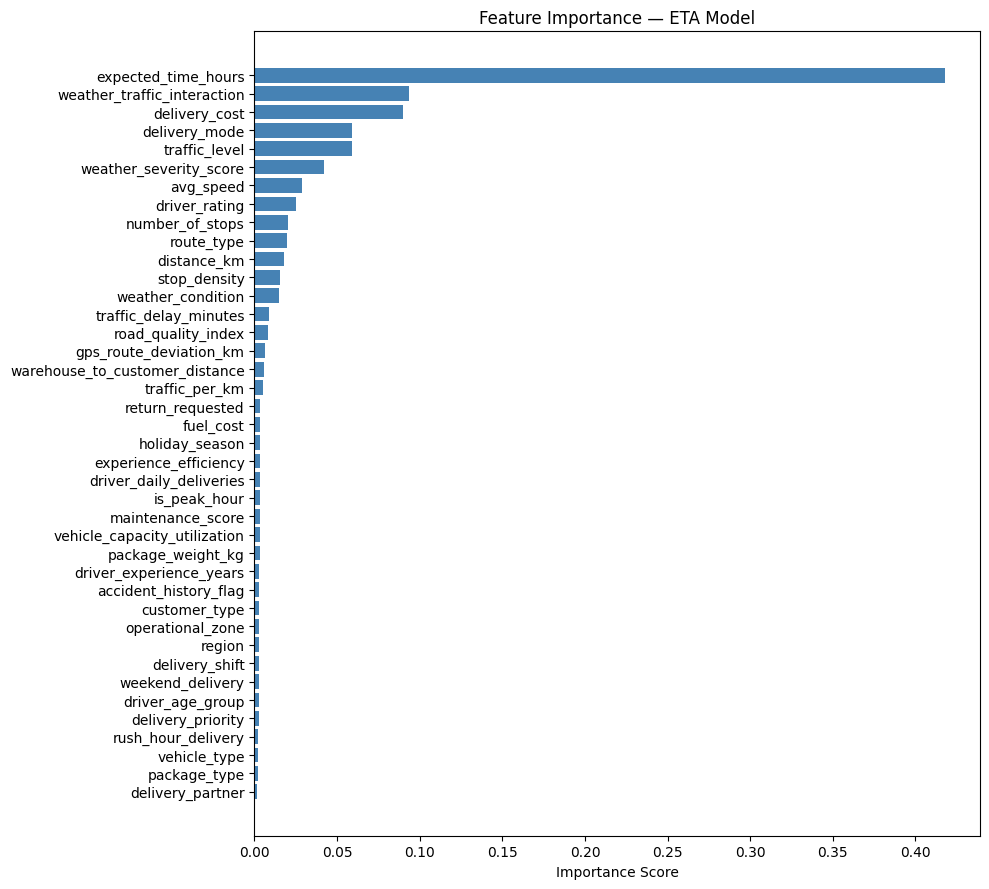

                       feature  importance
           expected_time_hours    0.418152
   weather_traffic_interaction    0.093764
                 delivery_cost    0.089916
                 delivery_mode    0.059221
                 traffic_level    0.059160
        weather_severity_score    0.042102
                     avg_speed    0.028688
                 driver_rating    0.025069
               number_of_stops    0.020275
                    route_type    0.019983
                   distance_km    0.017644
                  stop_density    0.015347
             weather_condition    0.014767
         traffic_delay_minutes    0.008859
            road_quality_index    0.008433
        gps_route_deviation_km    0.006312
warehouse_to_customer_distance    0.005715
                traffic_per_km    0.005039
              return_requested    0.003595
                     fuel_cost    0.003471
                holiday_season    0.003345
         experience_efficiency    0.003323
       driv

In [8]:
import matplotlib.pyplot as plt

feat_names = CATEGORICAL + NUMERIC
importances = eta_model.named_steps['reg'].feature_importances_

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
ax.set_title('Feature Importance — ETA Model')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(fi_df.sort_values('importance', ascending=False).to_string(index=False))

## 9. ETA estimator function (partial input supported)

In [9]:
def estimate_eta(user_input: dict) -> dict:
    """
    Estimate delivery ETA given any subset of known features.
    Missing features are left as NaN — the imputers handle them.

    Parameters
    ----------
    user_input : dict
        Any combination of keys from ALL_FEATURES.
        e.g. {'region': 'North Zone', 'distance_km': 350, 'weather_condition': 'rainy'}

    Returns
    -------
    dict with predicted_eta_hours, lower_bound, upper_bound (±MAE confidence)
    """
    row = {col: np.nan for col in ALL_FEATURES}
    row.update(user_input)

    input_df = pd.DataFrame([row], columns=ALL_FEATURES)
    eta_hours = float(eta_model.predict(input_df)[0])

    return {
        'predicted_eta_hours': round(eta_hours, 2),
        'lower_bound_hours':   round(max(0, eta_hours - mae), 2),
        'upper_bound_hours':   round(eta_hours + mae, 2),
    }


# ── Demos ───────────────────────────────────────────────────────────────────
print('1. Minimal input:')
print(estimate_eta({'region': 'South Zone', 'distance_km': 120}))

print('\n2. With traffic and weather:')
print(estimate_eta({
    'region':            'North Zone',
    'distance_km':       350,
    'weather_condition': 'rainy',
    'traffic_level':     'High',
    'vehicle_type':      'truck'
}))

print('\n3. Full feature set:')
print(estimate_eta({
    'delivery_partner':    'dhl',
    'package_type':        'electronics',
    'vehicle_type':        'ev van',
    'delivery_mode':       'same day',
    'region':              'East Zone',
    'weather_condition':   'clear',
    'traffic_level':       'Medium',
    'delivery_priority':   'High',
    'distance_km':         200,
    'package_weight_kg':   5.0,
    'expected_time_hours': 6,
    'delivery_cost':       900,
    'fuel_cost':           300,
    'driver_experience_years': 8,
    'traffic_delay_minutes': 10
}))

1. Minimal input:
{'predicted_eta_hours': 32.27, 'lower_bound_hours': 30.2, 'upper_bound_hours': 34.34}

2. With traffic and weather:
{'predicted_eta_hours': 34.35, 'lower_bound_hours': 32.28, 'upper_bound_hours': 36.41}

3. Full feature set:
{'predicted_eta_hours': 9.84, 'lower_bound_hours': 7.77, 'upper_bound_hours': 11.91}


In [10]:
df["delivery_time_hours"]

0        29.7
1        22.7
2        26.8
3        19.0
4        30.5
         ... 
24995    16.9
24996    23.1
24997    40.1
24998    20.6
24999    48.9
Name: delivery_time_hours, Length: 25000, dtype: float64

## 10. Score the full dataset & write ETA predictions to TiDB Cloud

In [11]:
# Score full dataset
df['predicted_eta_hours'] = eta_model.predict(df[ALL_FEATURES]).round(2)
df['eta_error_hours']     = (df['predicted_eta_hours'] - df[TARGET]).round(2)

# Fix: division by zero → replace with NaN (NULL in MySQL)
df['eta_error_pct'] = (
    df['eta_error_hours'] / df[TARGET].replace(0, np.nan) * 100
).round(2)

# Sanitise: replace inf/-inf with NaN so MySQL accepts them as NULL
for col in ['predicted_eta_hours', 'eta_error_hours', 'eta_error_pct']:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

# Columns to export
EXPORT_COLS = [
    'delivery_id', 'delivery_partner', 'package_type', 'vehicle_type',
    'delivery_mode', 'region', 'weather_condition', 'traffic_level',
    'delivery_priority', 'delivery_shift', 'route_type',
    'distance_km', 'package_weight_kg', 'delivery_cost', 'fuel_cost',
    'expected_time_hours', 'delivery_time_hours',
    'predicted_eta_hours', 'eta_error_hours', 'eta_error_pct',
    'order_date', 'pickup_date'
]
EXPORT_COLS = [c for c in EXPORT_COLS if c in df.columns]
eta_output_df = df[EXPORT_COLS].copy()

print(eta_output_df.head(3))
print('\nShape:', eta_output_df.shape)

   delivery_id delivery_partner      package_type vehicle_type delivery_mode  \
0       100000        delhivery  automobile parts         bike      same day   
1       100001       xpressbees         cosmetics       ev van       express   
2       100002        shadowfax         groceries        truck       two day   

        region weather_condition traffic_level delivery_priority  \
0        Surat             clear          High          Critical   
1       Bhopal              cold          High            Medium   
2  Bhubaneswar             rainy        Medium          Critical   

  delivery_shift  ... package_weight_kg  delivery_cost  fuel_cost  \
0        Evening  ...             46.96      1632.7206     625.85   
1      Afternoon  ...             47.39       640.1700     411.22   
2      Afternoon  ...             26.89      1448.1700    4060.55   

   expected_time_hours  delivery_time_hours  predicted_eta_hours  \
0                 31.9                 29.7            32.919

In [12]:
from sqlalchemy import Float

numeric_export_cols = [
    'delivery_id', 'distance_km', 'package_weight_kg', 'delivery_cost',
    'fuel_cost', 'expected_time_hours', 'delivery_time_hours',
    'predicted_eta_hours', 'eta_error_hours', 'eta_error_pct'
]
dtype_map = {c: Float for c in numeric_export_cols if c in EXPORT_COLS}

eta_output_df.to_sql(
    name='delivery_eta_predictions',
    con=engine,
    if_exists='replace',
    index=False,
    chunksize=200,
    method='multi',
    dtype=dtype_map,
)
print('Written to TiDB Cloud table: delivery_eta_predictions ✅')

Written to TiDB Cloud table: delivery_eta_predictions ✅


## 11. MySQL-friendly SQL views

Once the `delivery_eta_predictions` table exists in TiDB Cloud:

```sql
-- Average predicted ETA vs actual by partner
SELECT
    delivery_partner,
    COUNT(*)                                        AS total_deliveries,
    ROUND(AVG(delivery_time_hours), 2)              AS avg_actual_eta_hrs,
    ROUND(AVG(predicted_eta_hours), 2)              AS avg_predicted_eta_hrs,
    ROUND(AVG(ABS(eta_error_hours)), 2)             AS avg_abs_error_hrs
FROM delivery_eta_predictions
GROUP BY delivery_partner
ORDER BY avg_abs_error_hrs;

-- ETA accuracy by region, traffic level, and weather
SELECT
    region,
    traffic_level,
    weather_condition,
    ROUND(AVG(predicted_eta_hours), 2)  AS avg_predicted_eta_hrs,
    ROUND(AVG(ABS(eta_error_pct)), 2)   AS avg_abs_error_pct
FROM delivery_eta_predictions
GROUP BY region, traffic_level, weather_condition
ORDER BY avg_abs_error_pct DESC;

-- ETA vs actual by delivery mode and priority
SELECT
    delivery_mode,
    delivery_priority,
    ROUND(AVG(delivery_time_hours), 2)   AS avg_actual_hrs,
    ROUND(AVG(predicted_eta_hours), 2)   AS avg_predicted_hrs,
    ROUND(AVG(eta_error_pct), 2)         AS avg_error_pct
FROM delivery_eta_predictions
GROUP BY delivery_mode, delivery_priority
ORDER BY avg_actual_hrs;

-- High ETA error deliveries (off by more than 3 hours)
SELECT *
FROM delivery_eta_predictions
WHERE ABS(eta_error_hours) > 3
ORDER BY ABS(eta_error_hours) DESC;
```

## 12. Save the trained ETA model (optional)

In [ ]:
import joblib

joblib.dump(eta_model, 'eta_model.pkl')
print('ETA model saved → eta_model.pkl')

# To reload:
# eta_model = joblib.load('eta_model.pkl')

## 13. Quick re-use demo — single shipment prediction

In [13]:
new_shipment = {
    'delivery_partner':    'shadowfax',
    'package_type':        'groceries',
    'vehicle_type':        'bike',
    'delivery_mode':       'same day',
    'region':              'West Zone',
    'weather_condition':   'foggy',
    'traffic_level':       'Medium',
    'delivery_priority':   'Low',
    'distance_km':         95,
    'package_weight_kg':   3.2,
    'expected_time_hours': 4,
    'delivery_cost':       420,
    'fuel_cost':           200,
    'driver_experience_years': 5,
    'traffic_delay_minutes': 15
}

result = estimate_eta(new_shipment)

print('=== ETA Prediction ===')
print(f"Predicted ETA  : {result['predicted_eta_hours']} hours")
print(f"Confidence Band: {result['lower_bound_hours']} – {result['upper_bound_hours']} hours")

=== ETA Prediction ===
Predicted ETA  : 7.83 hours
Confidence Band: 5.76 – 9.89 hours


## 14. Verify predictions in TiDB Cloud

In [ ]:
df_sql = pd.read_sql(
    "SELECT * FROM delivery_eta_predictions LIMIT 10;",
    engine
)
print(df_sql.head())

In [16]:
output_df.to_csv('../outputs/eta_predictions.csv', index=False)

NameError: name 'output_df' is not defined